# Electron vs muon classification analysis

## First run - sc4422

### Parameters
wcte_classification.yaml

Overrides: 

data.dataset.transforms=['double_cover'] model.conv_pad_mode='circular' \
tasks.train.data_loaders.train.batch_size=1024 \
tasks.evaluate.data_loaders.test.batch_size=2048 \
tasks.train.data_loaders.validation.batch_size=2048 \
tasks.train.data_loaders.train.pre_transforms=[]


### Data/ Paths
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz' \
data.dataset.geometry_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/geometries/WCTE_geometry_v1.12.21.npz' \
data.dataset.mpmt_positions_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/mpmt_pos_files/WCTE_mpmt_position_correct_251125.npz' \
data.dataset.h5file='/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5'

### Disclaimer
New data (fixed FC and fixed mu) had 2 extra events than fitqun, causing some errors when separating out fitqun events to compare with the test outputs of the ML model. This was fixed using a different function / handling of the fitqun events (the missing indices section - using the event labels of h5 for the true labels of fitqun) -- old code assumed that h5 files were a subset of fitqun. The two events would have been removed in the physics cuts later on anyway, so should be fine, but should double check in case of any misalignment.

### Outputs
Run directory: /vols/hyperk/users/sc4422/first_run/outputs/pid/$DATE

### WatChMaL github version
workshop_2025-91-g158c799

# Imports and setup

Display settings for the notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize as opt
import sys
import h5py
import awkward as ak
import tabulate

In [3]:
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')
figure_dir = '/vols/hyperk/users/sc4422/first_run/analysis/figures'

In [4]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning, apply_binning
from analysis.utils.plotting import plot_legend
from analysis.classification import WatChMaLClassification, FiTQunClassification, plot_rocs, plot_efficiency_profile
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799-dirty


# True particle data from h5 file

In [5]:
outdir_ng = '/vols/hyperk/WCTE/ML_2025/cds_geometry/'
#idxs_path_new_geo = outdir_ng+'split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz'
idxs_path_new_geo = outdir_ng+'split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_ALL.npz'
test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

In [6]:
data_path_new_geo = outdir_ng+'/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5'
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [7]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum
    }

In [8]:
data_new_geo = get_values(h5_file_new_geo,test_idxs_new_geo)

# Making physics based cuts

In [9]:
def apply_cuts(data):
    veto_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25

    h5_electrons = (data['labels']==1)
    h5_muons = (data['labels']==2)
    selection_cut = (h5_electrons | h5_muons) 

    # select the true electron and muon events that pass the cuts
    cuts = (nhits_cut
            & towall_cut
            & veto_cut
            & selection_cut)
    return cuts

cuts_new_geo = apply_cuts(data_new_geo)

# could have applied the physical cuts first and then filtered, but I assume you want it to hold regardless bc physics cuts are flexible (unless there aren't supposed to have any)

# Loading FitQun results and filtering (assigning true labels)

In [10]:
# fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_full)

In [11]:
# def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
#     N = len(all_event_ids)
#     cut_start_idxs: list[int] = [0]
#     CUTOFF = 500
#     for i in range(N - 1):
#         if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
#             cut_start_idxs.append(i+ 1)
#     cut_start_idxs.append(len(all_event_ids)-1)
#     return cut_start_idxs

# ## because h5 seems to have extra event ids, return the indices to keep for both h5 and for fitqun (instead of only one direction)
# def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
#     missing_ids_fq = []
#     missing_inds_fq = []
#     missing_ids_h5 = []    
#     missing_inds_h5 = []
#     n_cuts = len(fq_cuts)
#     assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
#     for i in range(1, n_cuts):
#         fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
#         h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

#         fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
#         h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

#         assert fq_ids[0] < 100
#         assert fq_ids[-1] > 990

#         missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
#         if len(missing_both) > 0:
#             print(missing_both)

#         missing_fq = np.setdiff1d(fq_ids, h5_ids)
#         inds_fq = np.searchsorted(fq_ids, missing_fq)

#         missing_ids_fq.append(missing_fq.tolist())
#         missing_inds_fq.append(fq_start_idx + inds_fq)

#         missing_h5 = np.setdiff1d(h5_ids, fq_ids)
#         inds_h5 = np.searchsorted(h5_ids, missing_h5)

#         missing_ids_h5.append(missing_h5.tolist())
#         missing_inds_h5.append(h5_start_idx + inds_h5)
    
#     return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [12]:
# fq_event_ids = fq.chain['nevt']
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo['event_ids']

In [13]:
# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)
# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))

In [14]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo['event_ids'])), missing_indices_h5)

# print(len(fq_keep_idx) == len(h5_keep_idx)) # checking keeping overlap

In [15]:
# # Removing extra fq indices and assigning true labels

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
# # Cuts (on only common data)

# h5_electrons = data_new_geo['labels'][h5_keep_idx]==1
# h5_muons = data_new_geo['labels'][h5_keep_idx]==2

# h5_electron_flag = fq.electron_flag 
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)

# h5_muon_flag = fq.muon_flag 
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

# all_cuts = cuts_new_geo[h5_keep_idx] & reco_cut

In [17]:
# fitqun_runs_basic_cuts = FiTQunClassification(fq, "fiTQun New Geo basic cuts", data_new_geo['labels'][h5_keep_idx], fq_event_ids_new, cuts_new_geo[h5_keep_idx], linestyle='-')
# fitqun_runs_all_cuts = FiTQunClassification(fq, "fiTQun New Geo all cuts", data_new_geo['labels'][h5_keep_idx], fq_event_ids_new, all_cuts, linestyle='-')

# Loading ResNet results

In [18]:
results_dir = "/vols/hyperk/users/sc4422/first_run/"
#outputs = "outputs/pid/2026-02-05/15-23-40"
# outputs = 'outputs/pid/2026-02-19/12-22-39'
# outputs = 'outputs/pid/2026-02-24/14-33-30'
# outputs = 'outputs/pid/2026-03-17/13-58-50'
outputs = 'outputs/pid/2026-03-31/17-55-50'

pid_runs = [
    WatChMaLClassification(results_dir+outputs, "New Geo DC", data_new_geo['labels'], test_idxs_new_geo, cuts_new_geo, linestyle='-')
] # could filter by h5 index but cut out from the physical cuts (cuts_new_geo) anyway

# Setting up plotting style

In [19]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [20]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True
matplotlib.rcParams.update({
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

figure_dir = '/vols/hyperk/users/sc4422/first_run/analysis'

# Plots

## Training progression

In [21]:
# common_mask = np.zeros_like(cuts_new_geo, dtype=bool)
# common_mask[h5_keep_idx] = True

# cuts_new_geo_common = cuts_new_geo & common_mask

# print(np.array_equal(cuts_new_geo_common, cuts_new_geo)) # bc they are the same, the extra h5 events have already been cut from the fitqun events so no issue for the ml test ones

In [22]:
all_runs = pid_runs #+ [fitqun_runs_basic_cuts, fitqun_runs_all_cuts]

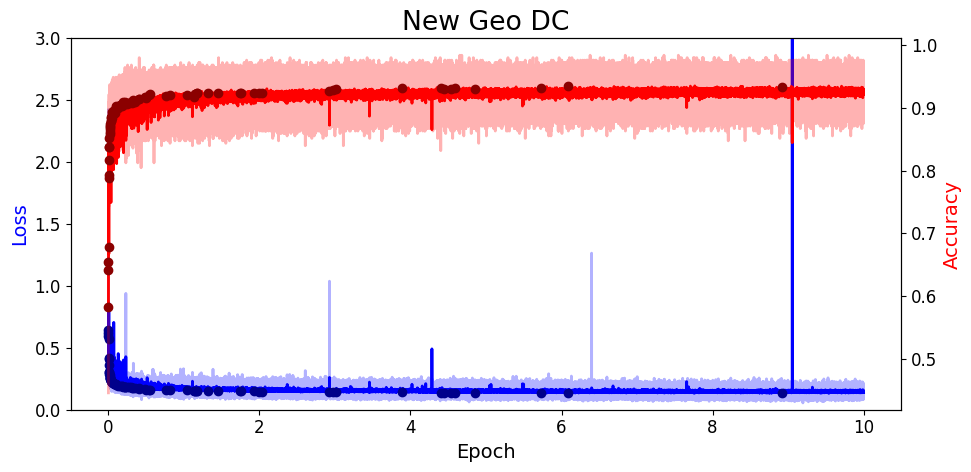

In [23]:
resnet_runs = pid_runs # last run is fiTQun run
figname = 'Loss_accuracy_curve'
for r in resnet_runs:
    fig, ax1, ax2, = r.plot_training_progression(legend=None, fig_size=(10,5), title=r.run_label, y_loss_lim=(0,3))
    #fig.savefig(figure+figname,bbox_inches='tight',dpi=300)
    #fig.savefig(figure_dir+figname,bbox_inches='tight',dpi=300)
# leg_fig, leg_ax = plot_legend((ax1, ax2))

# Plotting ROC Curves

In [24]:
e_labels = [1]
mu_labels = [2]

In [25]:
#help(plot_rocs)

New Geo DC: AUC = 0.9998259491201091
New Geo DC: AUC = 0.9998259491201091


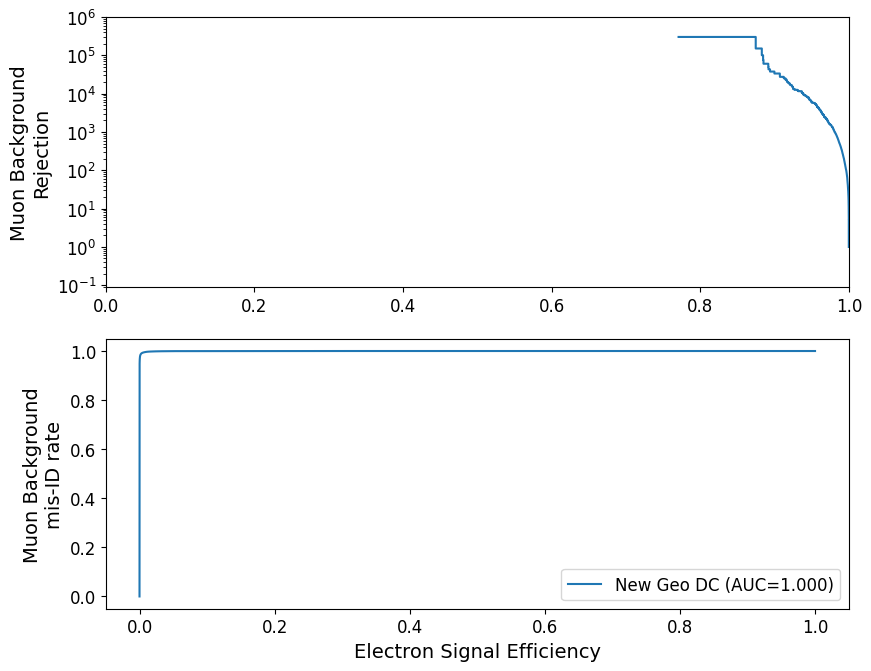

In [26]:
fig_2,ax_2 = plt.subplots(2,1,figsize=(9,7))
plot_rocs(all_runs, e_labels, mu_labels, ax=ax_2[0],x_label=None, y_label="Muon Background\nRejection", mode='rejection', 
          x_lim=(0.,1), legend=None, y_log=True, y_lim=[9e-2,1e6])
plot_rocs(all_runs, e_labels, mu_labels, ax=ax_2[1], x_label="Electron Signal Efficiency", y_label="Muon Background\nmis-ID rate", mode='efficiency', 
          legend=None)
# ax_2[0].set_xlim(-0.01,1.1)
# ax_2[1].set_xlim(-0.001,0.06)
# ax_2[1].set_ylim(0.8,1.01)
plt.legend(loc=4,fontsize=12)
fig_2.savefig(figure_dir+'PID_efficiency.png',bbox_inches='tight',dpi=300)

##  for fixed 0.1% muon mis-ID

### for each 50 MeV bin of reconstructed momentum, calculate the thresholds that reject 99.9% of muons and apply cut to all events

In [27]:
#help(WatChMaLClassification.cut_with_fixed_efficiency)

In [28]:
muon_rejection = 0.999
muon_efficiency = 1-muon_rejection
for r in all_runs:
    r.cut_with_fixed_efficiency(e_labels, mu_labels, muon_efficiency, select_labels=mu_labels)
#    r.cut_with_constant_binned_efficiency(e_labels, mu_labels, muon_efficiency, reco_mom_e_binning, select_labels=mu_labels)

New Geo DC: AUC = 0.9998259491201091
New Geo DC: AUC = 0.9998259491201091


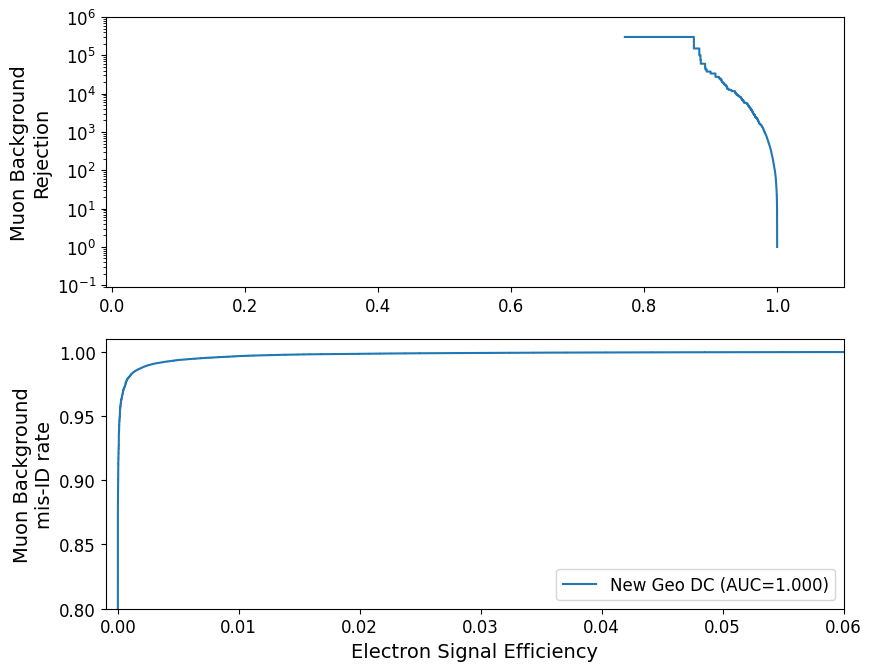

In [29]:
fig_2,ax_2 = plt.subplots(2,1,figsize=(9,7))
plot_rocs(all_runs, e_labels, mu_labels, ax=ax_2[0],x_label=None, y_label="Muon Background\nRejection", mode='rejection', 
          x_lim=(0.,1), legend=None, y_log=True, y_lim=[9e-2,1e6])
plot_rocs(all_runs, e_labels, mu_labels, ax=ax_2[1], x_label="Electron Signal Efficiency", y_label="Muon Background\nmis-ID rate", mode='efficiency', 
          legend=None)
ax_2[0].set_xlim(-0.01,1.1)
ax_2[1].set_xlim(-0.001,0.06)
ax_2[1].set_ylim(0.8,1.01)
plt.legend(loc=4,fontsize=12)
#fig_2.savefig(figure_dir+'PID_efficiency.png',bbox_inches='tight',dpi=300)


# confusion about this plots because i would expect it to be the same?

# Plotting comparison (against various physical quantities)

In [30]:
#help(plot_efficiency_profile)

mom_binning = [
    get_binning(data_new_geo['momentum'], 20, 0, 1000),
#     get_binning(data_new_geo['momentum'][h5_keep_idx], 20, 0, 1000),
#     get_binning(data_new_geo['momentum'][h5_keep_idx], 20, 0, 1000),
]

mom_binning_mu = [
    get_binning(data_new_geo['momentum'], 17, 150, 1000),
#     get_binning(data_new_geo['momentum'][h5_keep_idx], 17, 150, 1000),
#     get_binning(data_new_geo['momentum'][h5_keep_idx], 17, 150, 1000),
]

cos_zenith_binning = [
    get_binning(np.cos(data_new_geo['angles'][:,0]), 20, -1, 1),
#     get_binning(np.cos(data_new_geo['angles'][h5_keep_idx,0]), 20, -1, 1),
#     get_binning(np.cos(data_new_geo['angles'][h5_keep_idx,0]), 20, -1, 1),
]

azimuth_binning = [
    get_binning(data_new_geo['angles'][:,1]*180/np.pi, 20, -180, 180),
#     get_binning(data_new_geo['angles'][h5_keep_idx,1]*180/np.pi, 20, -180, 180),
#     get_binning(data_new_geo['angles'][h5_keep_idx,1]*180/np.pi, 20, -180, 180),
]

dwall_binning = [
    get_binning(data_new_geo['dwall'], 22, 50, 300),
#     get_binning(data_new_geo['dwall'][h5_keep_idx], 22, 50, 300),
#     get_binning(data_new_geo['dwall'][h5_keep_idx], 22, 50, 300),
]

towall_binning = [
    get_binning(data_new_geo['towall'], 30, 50, 800),
#     get_binning(data_new_geo['towall'][h5_keep_idx], 30, 50, 800),
#     get_binning(data_new_geo['towall'][h5_keep_idx], 30, 50, 800),
]

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


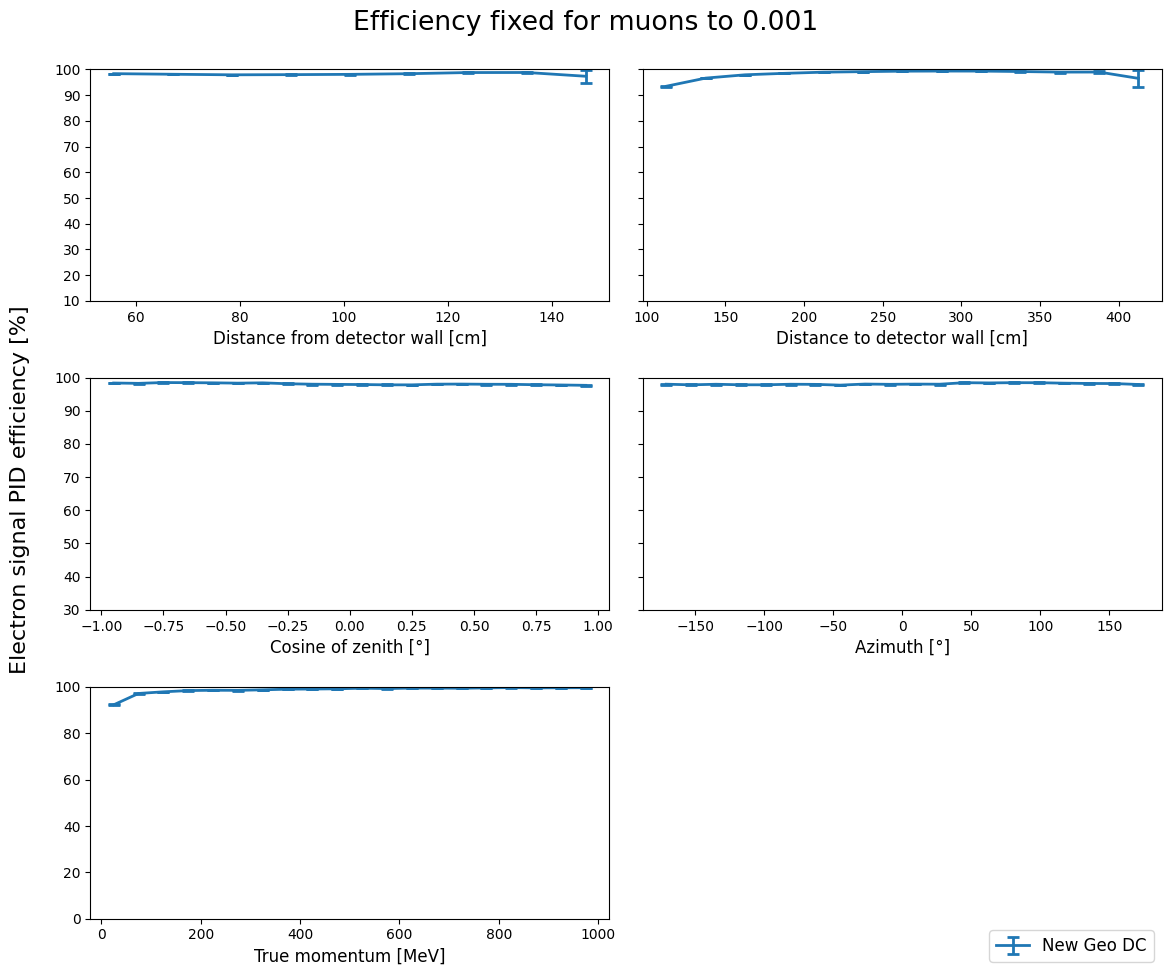

In [31]:
matplotlib.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

fig_e, ax_e = plt.subplots(3,2,figsize=(12,10),sharey='row',dpi=100)
resnet_runs = all_runs
for r in range(len(all_runs)):
    plot_efficiency_profile([all_runs[r]], mom_binning[r], select_labels=e_labels, ax=ax_e[2,0], x_label="True momentum [MeV]", y_label="Electron signal PID efficiency [%]", errors=True, x_errors=False,legend=None)
    plot_efficiency_profile([all_runs[r]], dwall_binning[r], select_labels=e_labels, ax=ax_e[0,0], x_label="Distance from detector wall [cm]", y_label="Electron signal PID efficiency [%]", errors=True, x_errors=False,legend=None)
    plot_efficiency_profile([all_runs[r]], towall_binning[r], select_labels=e_labels, ax=ax_e[0,1], x_label="Distance to detector wall [cm]", y_label="Electron signal PID efficiency [%]", errors=True, x_errors=False, legend=None)
    plot_efficiency_profile([all_runs[r]], cos_zenith_binning[r], select_labels=e_labels, ax=ax_e[1,0], x_label="Cosine of zenith [°]", y_label="Electron signal PID efficiency [%]", errors=True, x_errors=False, legend=None)
    plot_efficiency_profile([all_runs[r]], azimuth_binning[r], select_labels=e_labels, ax=ax_e[1,1], x_label="Azimuth [°]", y_label="Electron signal PID efficiency [%]", errors=True, x_errors=False,legend=None)

handles, labels = ax_e[0,0].get_legend_handles_labels()
fig_e.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)
ax_e[1,1].set_ylabel('')
ax_e[2,1].set_ylabel('')
ax_e[2,1].axis("off")
y_ticks_1 = np.arange(10, 101, 10)
y_ticks_2 = np.arange(30, 101, 10)
y_ticks_3 = np.arange(0, 101, 20)

ax_e[0, 0].set_yticks(y_ticks_1)
ax_e[0, 1].set_yticks(y_ticks_1)
ax_e[1, 0].set_yticks(y_ticks_2)
ax_e[1, 1].set_yticks(y_ticks_2)
ax_e[2, 0].set_yticks(y_ticks_3)

for i in range(ax_e.shape[0]):
    for j in range(ax_e.shape[1]):
        ax_e[i, j].set_ylabel('')
        
fig_e.supylabel("Electron signal PID efficiency [%]", fontsize=16)
fig_e.suptitle(f'Efficiency fixed for muons to {muon_efficiency:.3f}')
fig_e.subplots_adjust(wspace=0.2)
fig_e.savefig(figure_dir+'electron_PID_efficiency.png',bbox_inches='tight',dpi=300)


# even though efficiency is fixed, it's an average threhsold applied to all of a kinematic variable, so it varies across the binned graphs 

### Plot background mis-ID against true momentum, dwall, towall, zenith, azimuth

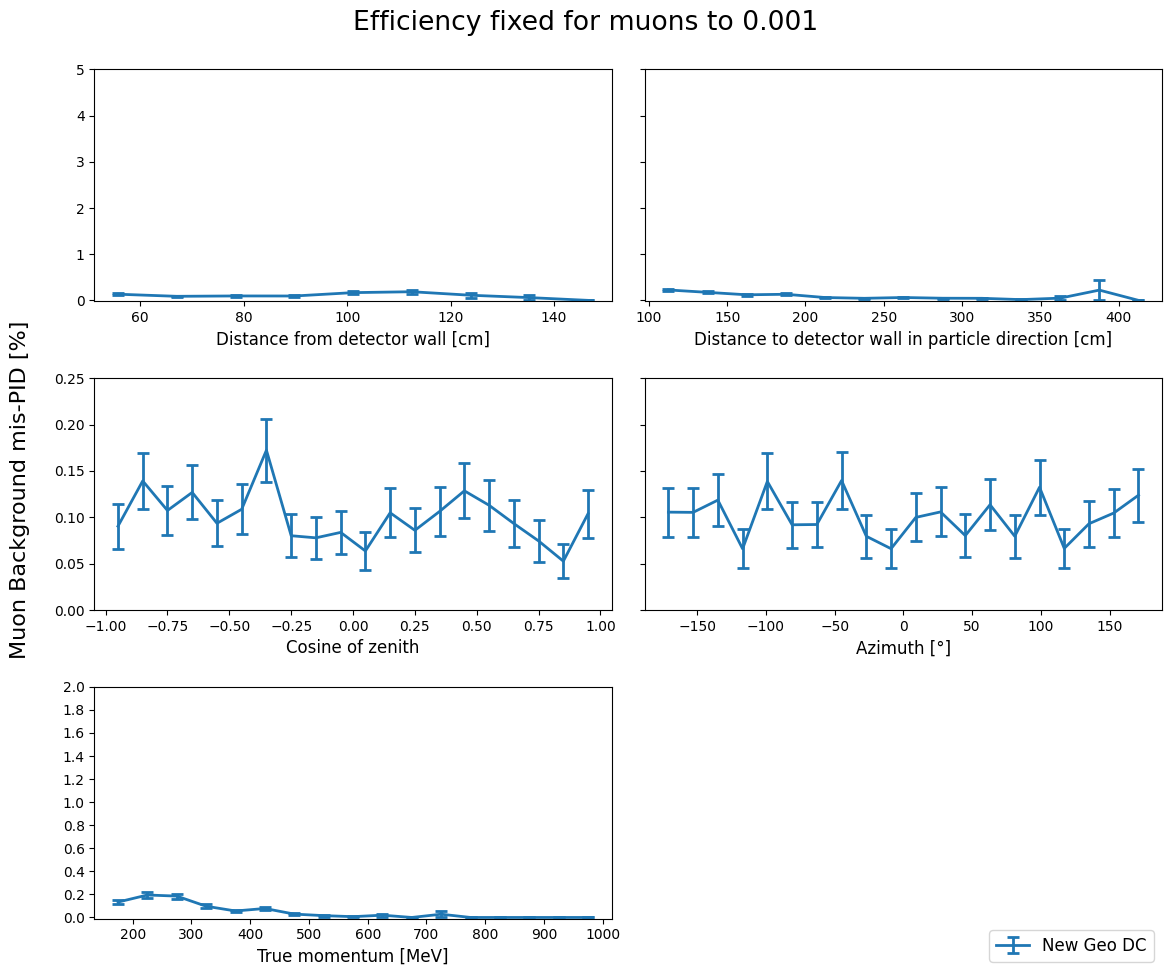

In [32]:
fig_mu, ax_mu = plt.subplots(3,2,figsize=(12,10),sharey='row',dpi=100)
for r in range(len(all_runs)):
    plot_efficiency_profile([all_runs[r]], mom_binning_mu[r], select_labels=mu_labels,ax=ax_mu[2,0], x_label="True momentum [MeV]", y_label="Muon background mis-PID", errors=True, x_errors=False,legend=None)
    plot_efficiency_profile([all_runs[r]], dwall_binning[r], select_labels=mu_labels,ax=ax_mu[0,0], x_label="Distance from detector wall [cm]", y_label="Muon background mis-PID [%]", errors=True, x_errors=False,legend=None)
    plot_efficiency_profile([all_runs[r]], towall_binning[r], select_labels=mu_labels, ax=ax_mu[0,1], x_label="Distance to detector wall in particle direction [cm]", y_label="Muon background mis-PID [%]", errors=True, x_errors=False,legend=None)
    plot_efficiency_profile([all_runs[r]], cos_zenith_binning[r], select_labels=mu_labels, ax=ax_mu[1,0], x_label="Cosine of zenith", y_label="Muon background mis-PID [%]", errors=True, x_errors=False,legend=None)
    plot_efficiency_profile([all_runs[r]], azimuth_binning[r], select_labels=mu_labels, ax=ax_mu[1,1], x_label="Azimuth [°]", y_label="Muon background mis-PID ", errors=True, x_errors=False,legend=None)

handles, labels = ax_mu[0,0].get_legend_handles_labels()
fig_mu.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=12)
ax_mu[1,1].set_ylabel('')
ax_mu[2,1].set_ylabel('')
ax_mu[2,1].axis("off")
y_ticks_1 = np.arange(0, 6, 1)
y_ticks_2 = np.arange(0, 0.3, 0.05)
y_ticks_3 = np.arange(0, 2.2, 0.2)

ax_mu[0, 0].set_yticks(y_ticks_1)
ax_mu[0, 1].set_yticks(y_ticks_1)
ax_mu[1, 0].set_yticks(y_ticks_2)
ax_mu[1, 1].set_yticks(y_ticks_2)
ax_mu[2, 0].set_yticks(y_ticks_3)

for i in range(ax_mu.shape[0]):
    for j in range(ax_mu.shape[1]):
        ax_mu[i, j].set_ylabel('')
        
fig_mu.supylabel("Muon Background mis-PID [%]", fontsize=16)
fig_mu.suptitle(f'Efficiency fixed for muons to {muon_efficiency:.3f}')
fig_mu.subplots_adjust(wspace=0.2)
fig_mu.savefig(figure_dir+'muon_PID_efficiency.png',bbox_inches='tight',dpi=300)